# HAM10000 Skin Lesion Dataset — Exploratory Data Analysis

This notebook performs exploratory data analysis (EDA) on the HAM10000
dermatoscopic skin lesion dataset.

### Objectives

1. Load and verify the HAM10000 metadata
2. Verify the available images
3. Analyze diagnostic class distribution
4. Visualize representative skin lesion images
5. Analyze image dimensions
6. Check metadata quality and missing values
7. Analyze lesion IDs and multiple images per lesion
8. Understand class imbalance before CNN training

### Dataset

HAM10000 contains 10,015 dermatoscopic images belonging to seven diagnostic
categories:

- `akiec` — Actinic keratoses / intraepithelial carcinoma
- `bcc` — Basal cell carcinoma
- `bkl` — Benign keratosis-like lesions
- `df` — Dermatofibroma
- `mel` — Melanoma
- `nv` — Melanocytic nevi
- `vasc` — Vascular lesions

In [1]:
# Core libraries
import os
from pathlib import Path

# Data handling
import pandas as pd
import numpy as np

# Image handling
from PIL import Image

# Visualization
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Project paths
project_root = Path.cwd().resolve().parent if "notebooks" in str(Path.cwd()) else Path.cwd().resolve()
DATASET_DIR = project_root / "Skin Dataset"
IMAGE_DIR = DATASET_DIR / "images"
METADATA_PATH = DATASET_DIR / "metadata" / "HAM10000_metadata.csv"

metadata = pd.read_csv(METADATA_PATH)

print("Libraries imported successfully.")
print("Dataset directory exists:", DATASET_DIR.exists())
print("Images folder exists:", IMAGE_DIR.exists())
print("Metadata file exists:", METADATA_PATH.exists())
print("Metadata shape:", metadata.shape)


Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully.
Dataset directory exists: True
Images folder exists: True
Metadata file exists: True
Metadata shape: (10015, 8)


In [2]:
# ---------------------------------------------------------
# Project structure:
#
# FYP_2026-2027/
# ├── notebooks/
# │   └── 01_eda.ipynb
# │
# └── Skin Dataset/
#     ├── images/
#     └── metadata/
#         └── HAM10000_metadata.csv
# ---------------------------------------------------------

PROJECT_ROOT = Path.cwd().resolve().parent if "notebooks" in str(Path.cwd()) else Path.cwd().resolve()
DATASET_DIR = PROJECT_ROOT / "Skin Dataset"
IMAGE_DIR = DATASET_DIR / "images"
METADATA_PATH = DATASET_DIR / "metadata" / "HAM10000_metadata.csv"

metadata = pd.read_csv(METADATA_PATH)

print("Dataset directory:")
print(DATASET_DIR.resolve())

print("\nMetadata file:")
print(METADATA_PATH.resolve())

print("\nImages folder:")
print(IMAGE_DIR.resolve())

# Check whether the paths exist
print("\nDataset directory exists:", DATASET_DIR.exists())
print("Metadata file exists:", METADATA_PATH.exists())
print("Images folder exists:", IMAGE_DIR.exists())


Dataset directory:
C:\FYP_2026-2027\Skin Dataset

Metadata file:
C:\FYP_2026-2027\Skin Dataset\metadata\HAM10000_metadata.csv

Images folder:
C:\FYP_2026-2027\Skin Dataset\images

Dataset directory exists: True
Metadata file exists: True
Images folder exists: True


In [3]:
print("Columns in metadata:")
print(metadata.columns.tolist())

Columns in metadata:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'dataset']


In [4]:
metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
 7   dataset       10015 non-null  str    
dtypes: float64(1), str(7)
memory usage: 626.1 KB


In [5]:
missing_values = metadata.isnull().sum()

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(metadata)) * 100
})

missing_table.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Missing Percentage
age,57,0.569146
lesion_id,0,0.000000
dx,0,0.000000
image_id,0,0.000000
dx_type,0,0.000000
sex,0,0.000000
localization,0,0.000000
dataset,0,0.000000


In [6]:
class_counts = metadata["dx"].value_counts()

print("Diagnostic classes:")
print(class_counts)

Diagnostic classes:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [7]:
class_distribution = pd.DataFrame({
    "Count": metadata["dx"].value_counts(),
    "Percentage": metadata["dx"].value_counts(normalize=True) * 100
})

class_distribution

,Count,Percentage
dx,,
nv,6705,66.949576
mel,1113,11.113330
bkl,1099,10.973540
bcc,514,5.132302
akiec,327,3.265102
vasc,142,1.417873
df,115,1.148278


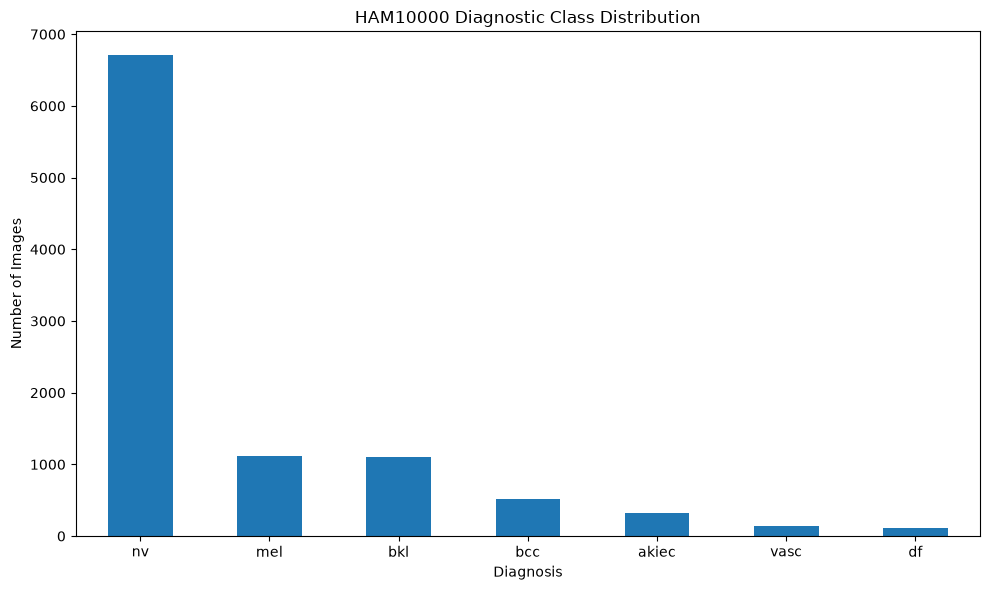

In [8]:
plt.figure(figsize=(10, 6))

class_counts.plot(kind="bar")

plt.title("HAM10000 Diagnostic Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Diagnostic Class Descriptions

| Code | Description |
|---|---|
| `akiec` | Actinic keratoses / intraepithelial carcinoma |
| `bcc` | Basal cell carcinoma |
| `bkl` | Benign keratosis-like lesions |
| `df` | Dermatofibroma |
| `mel` | Melanoma |
| `nv` | Melanocytic nevi |
| `vasc` | Vascular lesions |

In [9]:
# Find all JPEG images in the dataset image directory
image_files = list(IMAGE_DIR.glob("*.jpg"))

print("JPEG images found:", len(image_files))


JPEG images found: 10015


In [10]:
metadata_image_ids = set(
    metadata["image_id"].astype(str)
)

image_file_ids = {
    image.stem
    for image in image_files
}

missing_images = metadata_image_ids - image_file_ids
extra_images = image_file_ids - metadata_image_ids

print("Images in metadata:", len(metadata_image_ids))
print("Images found on disk:", len(image_file_ids))

print("\nMetadata entries without image:")
print(len(missing_images))

print("\nImages without metadata:")
print(len(extra_images))

Images in metadata: 10015
Images found on disk: 10015

Metadata entries without image:
0

Images without metadata:
0


In [11]:
metadata["image_path"] = metadata["image_id"].apply(
    lambda x: IMAGE_DIR / f"{x}.jpg"
)

metadata[["image_id", "dx", "image_path"]].head()


,image_id,dx,image_path
0,ISIC_0027419,bkl,C:\FYP_2026-2027\Skin Dataset\images\ISIC_0027...
1,ISIC_0025030,bkl,C:\FYP_2026-2027\Skin Dataset\images\ISIC_0025...
2,ISIC_0026769,bkl,C:\FYP_2026-2027\Skin Dataset\images\ISIC_0026...
3,ISIC_0025661,bkl,C:\FYP_2026-2027\Skin Dataset\images\ISIC_0025...
4,ISIC_0031633,bkl,C:\FYP_2026-2027\Skin Dataset\images\ISIC_0031...


In [12]:
# Test a few images

for i in range(5):
    image_path = metadata.iloc[i]["image_path"]
    
    with Image.open(image_path) as img:
        print(
            metadata.iloc[i]["image_id"],
            "->",
            img.size,
            img.mode
        )

ISIC_0027419 -> (600, 450) RGB
ISIC_0025030 -> (600, 450) RGB
ISIC_0026769 -> (600, 450) RGB
ISIC_0025661 -> (600, 450) RGB
ISIC_0031633 -> (600, 450) RGB


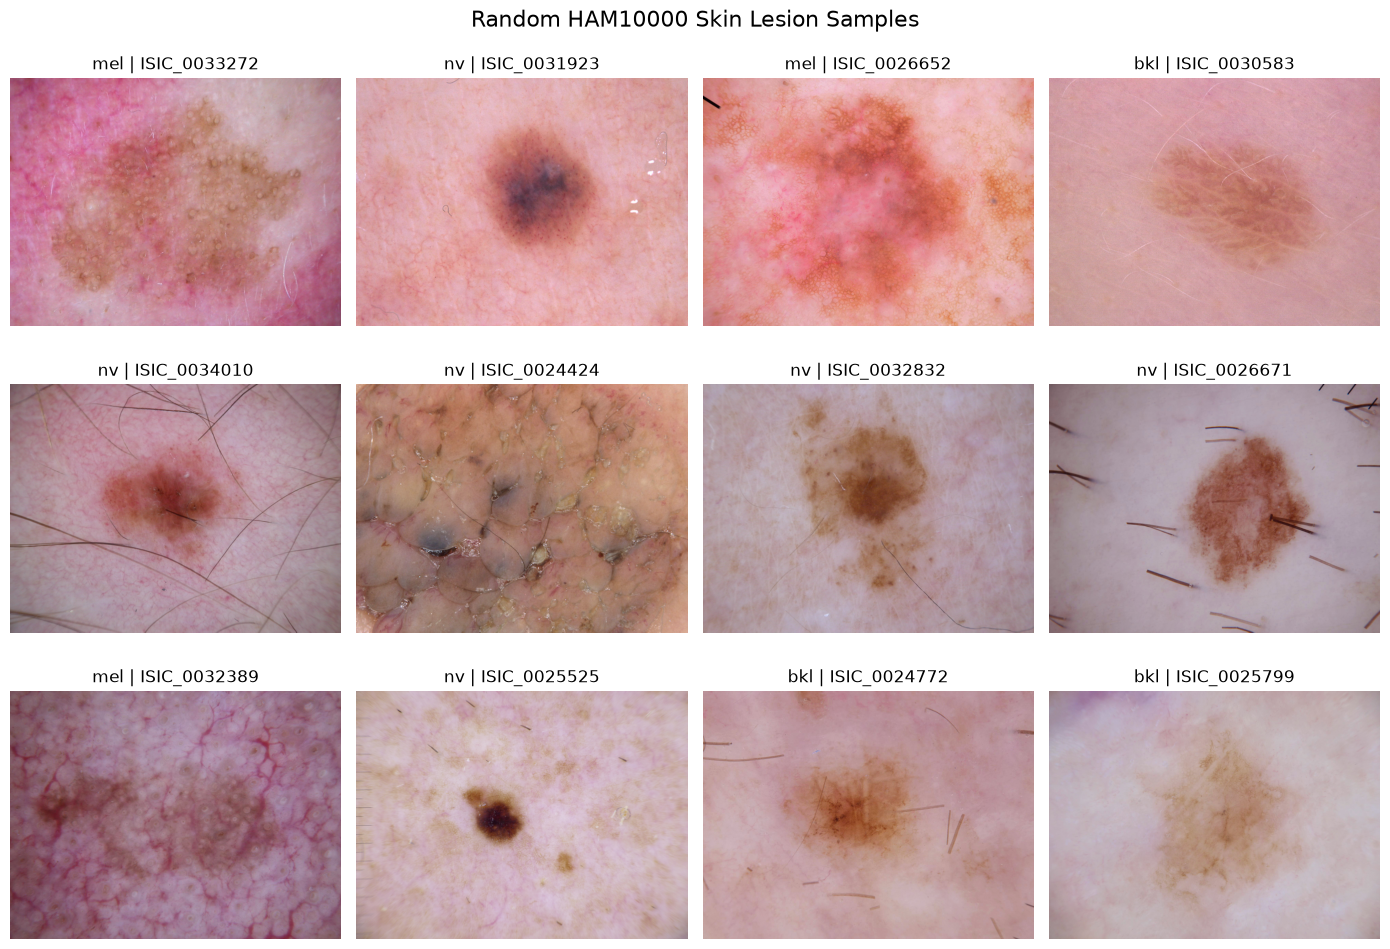

In [13]:
# Display 12 random images

sample = metadata.sample(
    n=12,
    random_state=42
).reset_index(drop=True)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(14, 10)
)

for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    
    image = Image.open(row["image_path"])
    
    ax.imshow(image)
    ax.set_title(f"{row['dx']} | {row['image_id']}")
    ax.axis("off")

plt.suptitle(
    "Random HAM10000 Skin Lesion Samples",
    fontsize=16
)

plt.tight_layout()
plt.show()

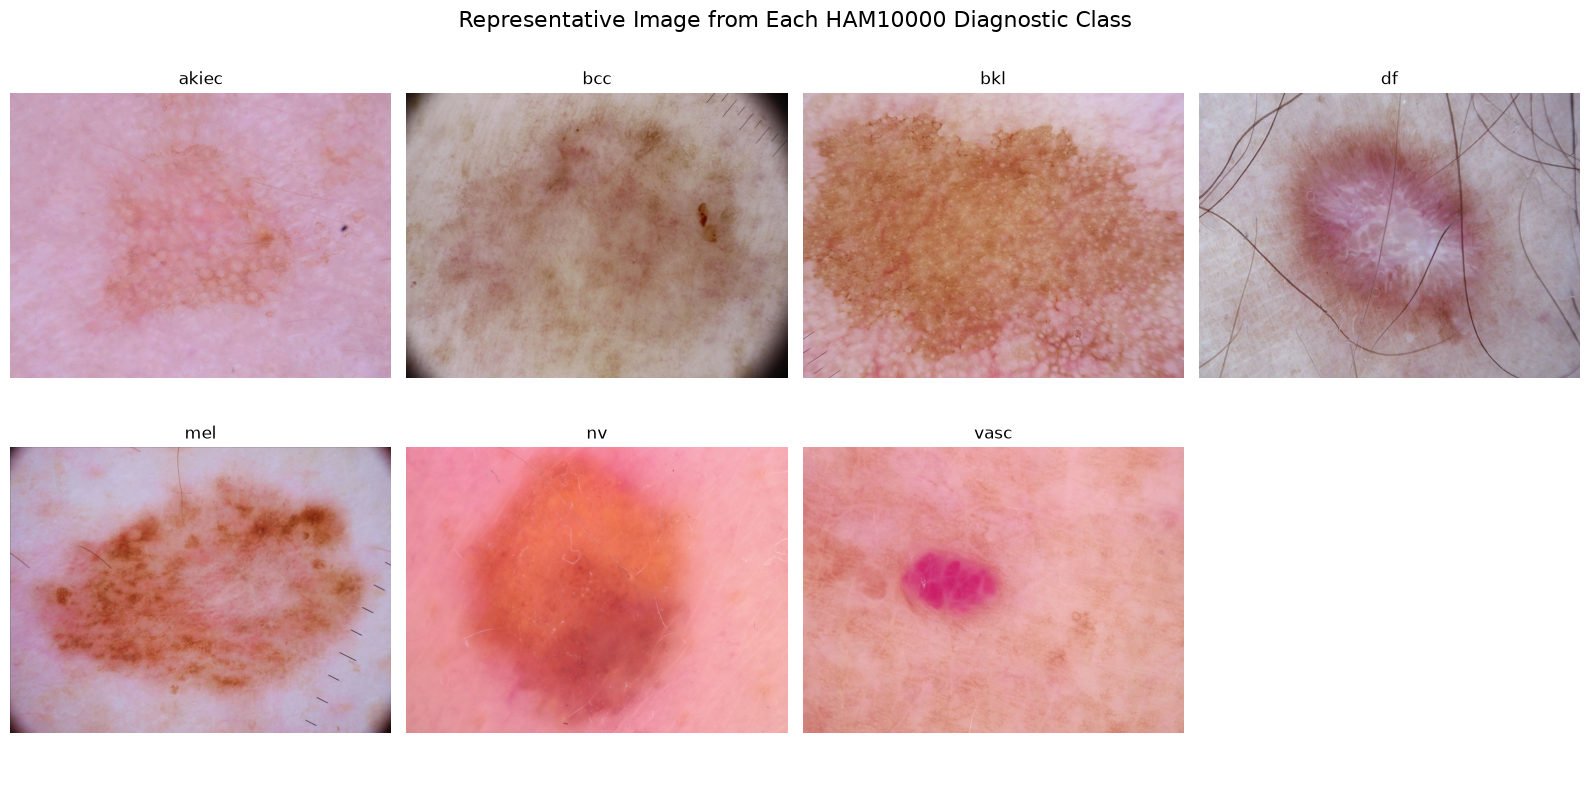

In [14]:
# Select one image from each diagnostic class

classes = metadata["dx"].unique()

fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8)
)

axes = axes.flatten()

for i, diagnosis in enumerate(sorted(classes)):
    
    row = metadata[
        metadata["dx"] == diagnosis
    ].sample(
        1,
        random_state=42
    ).iloc[0]
    
    image = Image.open(row["image_path"])
    
    axes[i].imshow(image)
    axes[i].set_title(diagnosis)
    axes[i].axis("off")

# Hide unused subplot
for j in range(len(classes), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Representative Image from Each HAM10000 Diagnostic Class",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [15]:
image_dimensions = []

for image_path in image_files:
    try:
        with Image.open(image_path) as img:
            width, height = img.size
            
        image_dimensions.append(
            (image_path.stem, width, height)
        )
        
    except Exception as e:
        print("Error:", image_path, e)

dimensions_df = pd.DataFrame(
    image_dimensions,
    columns=["image_id", "width", "height"]
)

dimensions_df.head()

,image_id,width,height
0,ISIC_0024306,600,450
1,ISIC_0024307,600,450
2,ISIC_0024308,600,450
3,ISIC_0024309,600,450
4,ISIC_0024310,600,450


In [16]:
dimensions_df[["width", "height"]].describe()

,width,height
count,10015.0,10015.0
mean,600.0,450.0
std,0.0,0.0
min,600.0,450.0
25%,600.0,450.0
50%,600.0,450.0
75%,600.0,450.0
max,600.0,450.0


In [17]:
print("Most common image dimensions:")

dimensions_df.groupby(
    ["width", "height"]
).size().sort_values(
    ascending=False
).head(10)

Most common image dimensions:


width  height
600    450       10015
dtype: int64

In [18]:
unique_lesions = metadata["lesion_id"].nunique()

print("Total images:", len(metadata))
print("Unique lesions:", unique_lesions)
print(
    "Images per lesion on average:",
    len(metadata) / unique_lesions
)

Total images: 10015
Unique lesions: 7470
Images per lesion on average: 1.3406961178045516


In [19]:
images_per_lesion = metadata["lesion_id"].value_counts()

print("Images per lesion distribution:")
print(images_per_lesion.describe())

Images per lesion distribution:
count    7470.000000
mean        1.340696
std         0.633970
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         6.000000
Name: count, dtype: float64


In [20]:
multiple_image_lesions = (
    images_per_lesion[
        images_per_lesion > 1
    ]
)

print(
    "Number of lesions with multiple images:",
    len(multiple_image_lesions)
)

multiple_image_lesions.head(20)

Number of lesions with multiple images: 1956


lesion_id
HAM_0003789    6
HAM_0000835    6
HAM_0001863    6
HAM_0005263    6
HAM_0000893    5
HAM_0007427    5
HAM_0007343    5
HAM_0007367    5
HAM_0002364    5
HAM_0003847    4
HAM_0003021    4
HAM_0000959    4
HAM_0002008    4
HAM_0000237    4
HAM_0001721    4
HAM_0002042    4
HAM_0001781    4
HAM_0002824    4
HAM_0003602    4
HAM_0007558    4
Name: count, dtype: int64

In [21]:
multiple_image_lesions = (
    images_per_lesion[
        images_per_lesion > 1
    ]
)

print(
    "Number of lesions with multiple images:",
    len(multiple_image_lesions)
)

multiple_image_lesions.head(20)

Number of lesions with multiple images: 1956


lesion_id
HAM_0003789    6
HAM_0000835    6
HAM_0001863    6
HAM_0005263    6
HAM_0000893    5
HAM_0007427    5
HAM_0007343    5
HAM_0007367    5
HAM_0002364    5
HAM_0003847    4
HAM_0003021    4
HAM_0000959    4
HAM_0002008    4
HAM_0000237    4
HAM_0001721    4
HAM_0002042    4
HAM_0001781    4
HAM_0002824    4
HAM_0003602    4
HAM_0007558    4
Name: count, dtype: int64

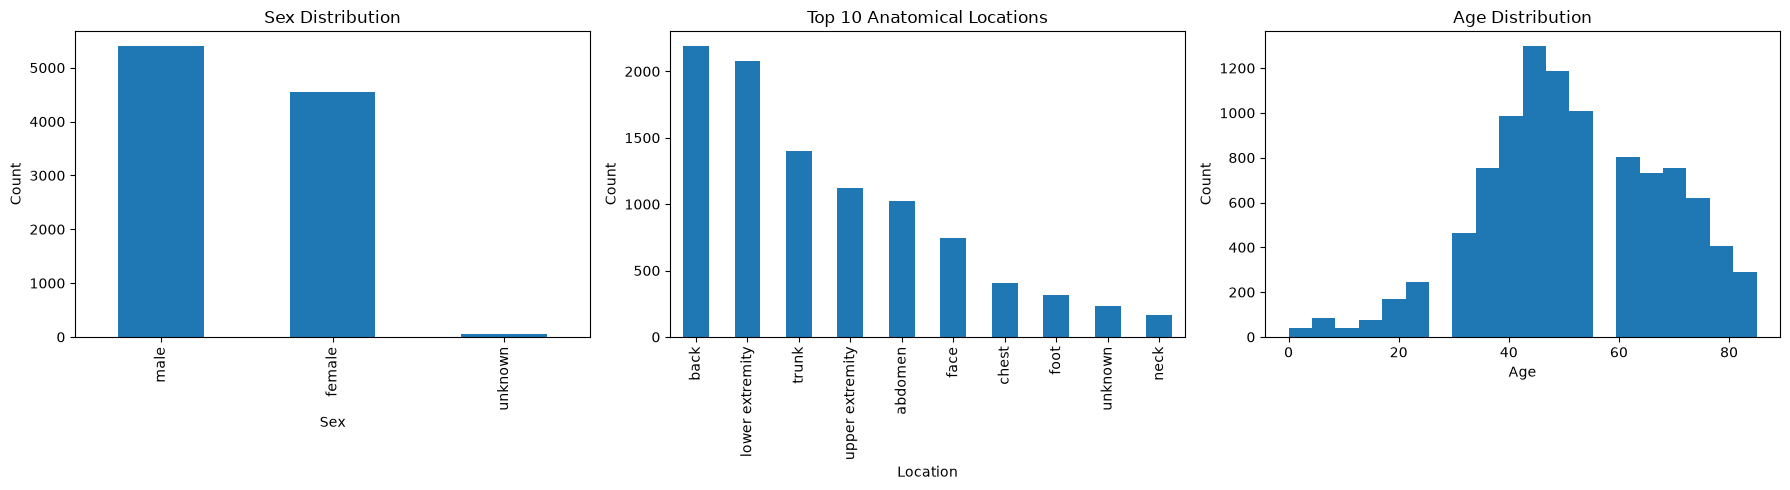

In [22]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

# Sex
metadata["sex"].value_counts().plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Sex Distribution")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Count")

# Localization
metadata["localization"].value_counts().head(10).plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Top 10 Anatomical Locations")
axes[1].set_xlabel("Location")
axes[1].set_ylabel("Count")

# Age
metadata["age"].dropna().plot(
    kind="hist",
    bins=20,
    ax=axes[2]
)

axes[2].set_title("Age Distribution")
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

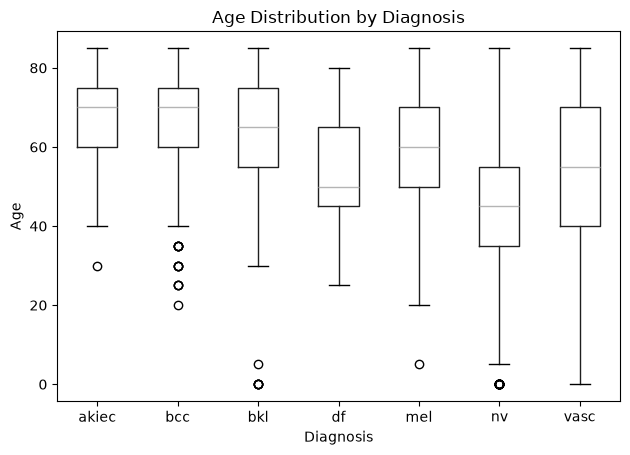

In [23]:
plt.figure(figsize=(12, 6))

metadata.boxplot(
    column="age",
    by="dx",
    grid=False
)

plt.title("Age Distribution by Diagnosis")
plt.suptitle("")
plt.xlabel("Diagnosis")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

In [24]:
duplicate_image_ids = metadata[
    metadata["image_id"].duplicated(keep=False)
]

print(
    "Duplicate image IDs:",
    duplicate_image_ids["image_id"].nunique()
)

duplicate_image_ids.head()

Duplicate image IDs: 0


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,image_path


In [25]:
duplicate_rows = metadata.duplicated().sum()

print("Duplicate metadata rows:", duplicate_rows)

Duplicate metadata rows: 0


In [26]:
print("=" * 60)
print("HAM10000 DATASET SUMMARY")
print("=" * 60)

print(f"Total metadata records : {len(metadata)}")
print(f"Images found           : {len(image_files)}")
print(f"Unique lesions         : {metadata['lesion_id'].nunique()}")
print(f"Diagnostic classes     : {metadata['dx'].nunique()}")
print(f"Missing metadata cells : {metadata.isnull().sum().sum()}")
print(f"Duplicate image IDs    : {metadata['image_id'].duplicated().sum()}")

print("\nDiagnostic classes:")
for diagnosis in sorted(metadata["dx"].unique()):
    count = (metadata["dx"] == diagnosis).sum()
    print(f"  {diagnosis:6s}: {count}")

HAM10000 DATASET SUMMARY
Total metadata records : 10015
Images found           : 10015
Unique lesions         : 7470
Diagnostic classes     : 7
Missing metadata cells : 57
Duplicate image IDs    : 0

Diagnostic classes:
  akiec : 327
  bcc   : 514
  bkl   : 1099
  df    : 115
  mel   : 1113
  nv    : 6705
  vasc  : 142
